# Tool-Call Transition Graph ("Decision Tree")

Reconstructs the per-diagnosis tool-call transition graph (à la the paper's "Decision Tree" figure —
majority path in black, all paths in gray, edges labeled with transition counts) from the raw simulation
`.jsonl` conversation traces in `src/raw/evaluable_outputs/baseline/EVALUABLE_OUTPUTS/<diagnosis>/`.

**This isn't reproducing paper code** — no transition-graph builder exists anywhere in this repo (checked:
no `networkx`/`graphviz` usage outside `dataset/consort_tracker.py`, which is an unrelated CONSORT diagram).
This notebook reimplements the idea from the raw tool-call sequences that are actually available.

**Sample size matters a lot here.** A single conversation only contributes ~5-10 transitions. The paper's edge
counts (e.g. 137, 102, 88 for a single edge in the Appendicitis panel) imply aggregation over on the order of
100+ patients per diagnosis — `config.SELECTED_HADM_IDS["appendicitis"]` alone lists 148 candidate hadm_ids.
With only 1-2 simulated patients, the graph below will be sparse and mostly-1s — useful to sanity check the
pipeline, but not comparable to the paper's figure until you've run many more patients (raise `MAX_SAMPLES` in
`run_simulation.ipynb`, and prefer `03_make_dataset_full.sh` over the 20-admission-capped small build so there
are enough admissions to sample from).

In [2]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / 'dataset').exists() and (candidate / 'paths.py').exists():
        candidate_str = str(candidate.resolve())
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

In [3]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

from paths import EVALUABLE_OUTPUTS_BASELINE_DIR

## 1. Pick a diagnosis and load its conversation traces

In [4]:
DIAGNOSIS = "appendicitis"  # change to whichever diagnosis you've simulated

conversation_dir = Path(EVALUABLE_OUTPUTS_BASELINE_DIR) / DIAGNOSIS
conversation_files = sorted(conversation_dir.glob("*.jsonl"))
print(f"Found {len(conversation_files)} conversation(s) for {DIAGNOSIS!r}: {conversation_dir}")
for f in conversation_files:
    print(" -", f.name)

Found 1 conversation(s) for 'appendicitis': /home/mwei26/codebase/MIRA/src/raw/evaluable_outputs/baseline/EVALUABLE_OUTPUTS/appendicitis
 - appendicitis_20345216_conversation_1.jsonl


## 2. Extract the ordered tool-call sequence per conversation

Each `.jsonl` file has one JSON object with a `med_assistant` list of chat messages. Assistant turns that made
a tool call carry a `tool_calls` list (parallel calls are disabled in this pipeline, so it's always length 1).
We prepend a synthetic `"Clinical History"` start node (the free-text history-taking phase before the first
tool call) to match the paper's diagram.

In [5]:
# Map raw tool/function names to the display labels used in the paper's diagram
TOOL_LABELS = {
    "PhysicalExamination": "Physical Examination",
    "Plan": "Plan",
    "LabRequestList": "Lab Tests",
    "UrineRequestList": "Urine Tests",
    "MicrobiologyRequestList": "Microbiology",
    "RadiologyRequestFHIR": "Imaging",
    "MedicationRequestList": "Medication",
    "ProcedureSearch": "Search",
    "ProcedureRequestFHIR": "Intervention",
    "Finish": "Admission",
    "CloseCase": "Admission",
    "PatientHistory": "Patient Info",
    "VitalSigns": "Vital Signs",
}

START_NODE = "Clinical History"


def extract_tool_sequence(conversation_path: Path) -> list[str]:
    """Return the ordered list of display-label tool names called in one conversation, prefixed with START_NODE."""
    with open(conversation_path) as f:
        record = json.loads(f.readline())

    sequence = [START_NODE]
    for turn in record["med_assistant"]:
        if turn.get("role") == "assistant" and turn.get("tool_calls"):
            for tool_call in turn["tool_calls"]:
                name = tool_call["function"]["name"]
                sequence.append(TOOL_LABELS.get(name, name))
    return sequence


sequences = [extract_tool_sequence(f) for f in conversation_files]
for f, seq in zip(conversation_files, sequences):
    print(f.name, "->", " -> ".join(seq))

appendicitis_20345216_conversation_1.jsonl -> Clinical History -> Physical Examination -> Plan -> Lab Tests -> Urine Tests -> Imaging -> Medication -> Search -> Intervention -> Admission


## 3. Count transitions across all conversations

In [6]:
edge_counts = Counter()
for seq in sequences:
    for src, dst in zip(seq, seq[1:]):
        edge_counts[(src, dst)] += 1

print(f"{len(edge_counts)} distinct edges from {len(sequences)} conversation(s):")
for (src, dst), count in sorted(edge_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {src:22s} -> {dst:22s}  {count}")

9 distinct edges from 1 conversation(s):
  Clinical History       -> Physical Examination    1
  Physical Examination   -> Plan                    1
  Plan                   -> Lab Tests               1
  Lab Tests              -> Urine Tests             1
  Urine Tests            -> Imaging                 1
  Imaging                -> Medication              1
  Medication             -> Search                  1
  Search                 -> Intervention            1
  Intervention           -> Admission               1


## 4. Build the graph and mark the majority path

For each node, the single outgoing edge with the highest count is the "majority path" (drawn thicker/black);
every other edge is "all paths" (drawn thin/gray), matching the paper's legend.

In [7]:
G = nx.DiGraph()
for (src, dst), count in edge_counts.items():
    G.add_edge(src, dst, weight=count)

# majority outgoing edge per node
majority_edges = set()
out_edges_by_node = defaultdict(list)
for src, dst, data in G.edges(data=True):
    out_edges_by_node[src].append((dst, data["weight"]))

for src, out_edges in out_edges_by_node.items():
    best_dst = max(out_edges, key=lambda x: x[1])[0]
    majority_edges.add((src, best_dst))

print("Majority path edges:")
for src, dst in majority_edges:
    print(f"  {src} -> {dst}  ({G[src][dst]['weight']})")

Majority path edges:
  Urine Tests -> Imaging  (1)
  Imaging -> Medication  (1)
  Plan -> Lab Tests  (1)
  Clinical History -> Physical Examination  (1)
  Search -> Intervention  (1)
  Medication -> Search  (1)
  Intervention -> Admission  (1)
  Physical Examination -> Plan  (1)
  Lab Tests -> Urine Tests  (1)


## 5. Draw it

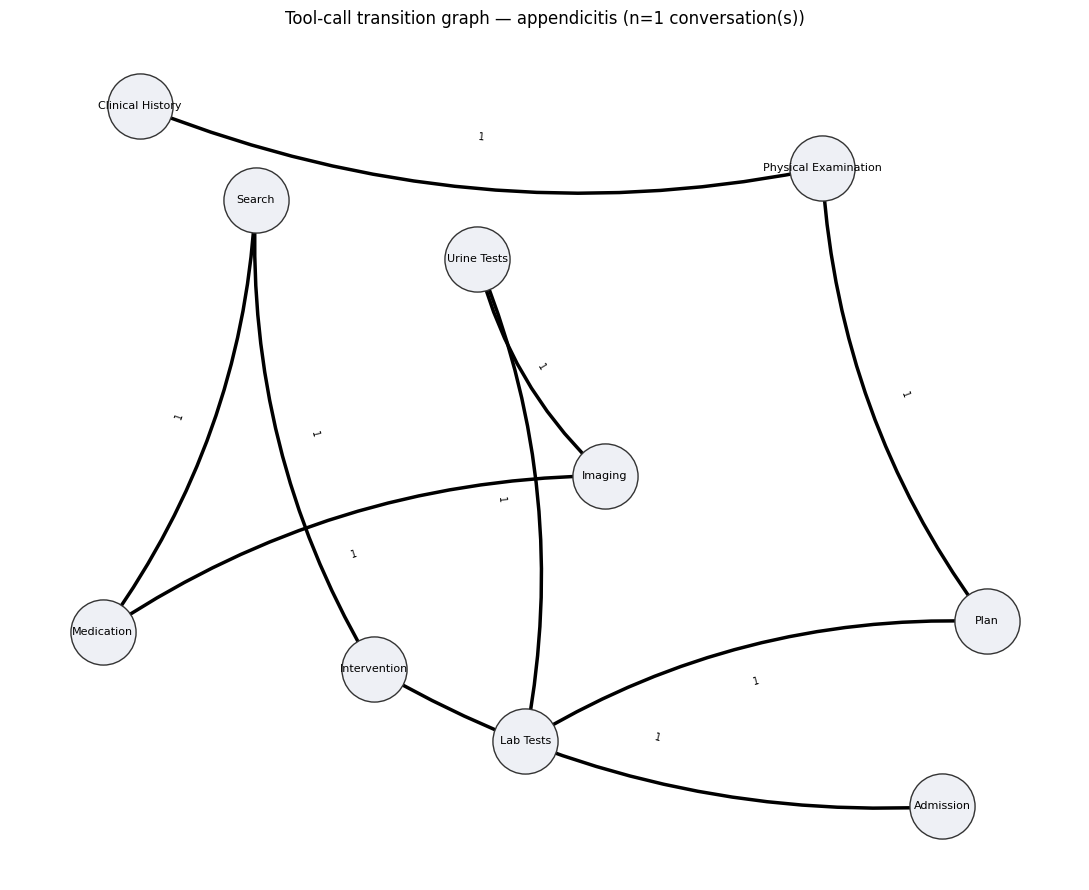

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.spring_layout(G, seed=7, k=1.4)

majority = [e for e in G.edges() if e in majority_edges]
other = [e for e in G.edges() if e not in majority_edges]

nx.draw_networkx_nodes(G, pos, node_color="#eef0f5", edgecolors="#333", node_size=2200, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

nx.draw_networkx_edges(
    G, pos, edgelist=other, edge_color="#bbb", width=1,
    connectionstyle="arc3,rad=0.15", arrowsize=12, ax=ax,
)
nx.draw_networkx_edges(
    G, pos, edgelist=majority, edge_color="black", width=2.5,
    connectionstyle="arc3,rad=0.15", arrowsize=16, ax=ax,
)

edge_labels = {(u, v): d["weight"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title(f"Tool-call transition graph — {DIAGNOSIS} (n={len(sequences)} conversation(s))")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. All diagnoses at once (optional)

Repeats steps 1-5 for every diagnosis that has simulation output, as a grid — closer to the paper's multi-panel
layout. Same caveat: panels backed by only a handful of conversations will look sparse/trivial compared to the
paper.

In [ ]:
available_diagnoses = sorted(
    p.name for p in Path(EVALUABLE_OUTPUTS_BASELINE_DIR).glob("*") if p.is_dir()
)
print("Diagnoses with simulation output:", available_diagnoses)

fig, axes = plt.subplots(
    nrows=(len(available_diagnoses) + 1) // 2, ncols=2, figsize=(16, 7 * ((len(available_diagnoses) + 1) // 2))
)
axes = axes.flatten() if len(available_diagnoses) > 1 else [axes]

for ax, diagnosis in zip(axes, available_diagnoses):
    files = sorted((Path(EVALUABLE_OUTPUTS_BASELINE_DIR) / diagnosis).glob("*.jsonl"))
    seqs = [extract_tool_sequence(f) for f in files]

    counts = Counter()
    for seq in seqs:
        for src, dst in zip(seq, seq[1:]):
            counts[(src, dst)] += 1

    Gd = nx.DiGraph()
    for (src, dst), count in counts.items():
        Gd.add_edge(src, dst, weight=count)

    out_by_node = defaultdict(list)
    for src, dst, data in Gd.edges(data=True):
        out_by_node[src].append((dst, data["weight"]))
    maj = {(src, max(out, key=lambda x: x[1])[0]) for src, out in out_by_node.items()}

    pos_d = nx.spring_layout(Gd, seed=7, k=1.4)
    nx.draw_networkx_nodes(Gd, pos_d, node_color="#eef0f5", edgecolors="#333", node_size=1200, ax=ax)
    nx.draw_networkx_labels(Gd, pos_d, font_size=6, ax=ax)
    nx.draw_networkx_edges(Gd, pos_d, edgelist=[e for e in Gd.edges() if e not in maj], edge_color="#bbb", width=1, connectionstyle="arc3,rad=0.15", arrowsize=8, ax=ax)
    nx.draw_networkx_edges(Gd, pos_d, edgelist=[e for e in Gd.edges() if e in maj], edge_color="black", width=2, connectionstyle="arc3,rad=0.15", arrowsize=10, ax=ax)
    ax.set_title(f"{diagnosis} (n={len(seqs)})", fontsize=10)
    ax.axis("off")

for ax in axes[len(available_diagnoses):]:
    ax.axis("off")

plt.tight_layout()
plt.show()